# K-Means Clustering 

## Objective
In this project, we will learn:

- What is K-Means Clustering?
- How to prepare data for clustering
- How to find the optimal value of K
- How to train the K-Means model
- How to visualize clusters
- How to evaluate clustering results

Dataset used: `Live.csv`


## 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Explanation
- numpy → Mathematical operations
- pandas → Dataset handling
- matplotlib & seaborn → Visualization
- MinMaxScaler → Feature scaling
- KMeans → Clustering algorithm
- silhouette_score → Cluster evaluation

## 2. Load Dataset

In [3]:
df = pd.read_csv('Live.csv')
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


## 3. Basic Dataset Information

In [21]:
print(df.shape)
df.info()

(7050, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object

## 4. Check Missing Values

In [4]:
df.isnull().sum()

status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64

## 5. Remove Unnecessary Columns

In [5]:
df.drop(['Column1', 'Column2', 'Column3', 'Column4'], axis=1, inplace=True)
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0


## 6. Explore Categorical Columns

In [7]:
print(df['status_type'].unique())
print(df['status_type'].nunique())

['video' 'photo' 'link' 'status']
4


## 7. Remove Non-Useful Text Columns

In [8]:
df.drop(['status_id', 'status_published'], axis=1, inplace=True)
df.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,529,512,262,432,92,3,1,1,0
1,photo,150,0,0,150,0,0,0,0,0
2,video,227,236,57,204,21,1,1,0,0
3,photo,111,0,0,111,0,0,0,0,0
4,photo,213,0,0,204,9,0,0,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB


## 8. Convert Categorical Data into Numerical Form

In [10]:
df['status_type'] = df['status_type'].astype('category').cat.codes
df.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,3,529,512,262,432,92,3,1,1,0
1,1,150,0,0,150,0,0,0,0,0
2,3,227,236,57,204,21,1,1,0,0
3,1,111,0,0,111,0,0,0,0,0
4,1,213,0,0,204,9,0,0,0,0


In [11]:
df.describe()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,1.704965,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191
std,0.942399,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000
max,3.000000,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000


## 9. Feature Scaling

In [13]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
# scaled_data
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1.000000,0.112314,0.024393,0.076519,0.091720,0.140030,0.010791,0.006369,0.019608,0.0
1,0.333333,0.031847,0.000000,0.000000,0.031847,0.000000,0.000000,0.000000,0.000000,0.0
2,1.000000,0.048195,0.011243,0.016647,0.043312,0.031963,0.003597,0.006369,0.000000,0.0
3,0.333333,0.023567,0.000000,0.000000,0.023567,0.000000,0.000000,0.000000,0.000000,0.0
4,0.333333,0.045223,0.000000,0.000000,0.043312,0.013699,0.000000,0.000000,0.000000,0.0


In [14]:
scaled_df.describe()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,0.568322,0.048857,0.010689,0.011689,0.045657,0.019374,0.004638,0.004436,0.004778,0.003651
std,0.314133,0.098222,0.042384,0.038435,0.095429,0.060842,0.031366,0.025205,0.031317,0.023446
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.333333,0.003609,0.000000,0.000000,0.003609,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.333333,0.012633,0.000191,0.000000,0.012314,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.046497,0.001096,0.001168,0.039225,0.004566,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 10. Find Optimal Number of Clusters (Elbow Method)

In [15]:
inertia_values = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_df)
    inertia_values.append(kmeans.inertia_)

In [33]:
inertia_values

[899.1609334281561,
 237.75726404419646,
 161.5963340003362,
 127.31215896781812,
 96.24993195940576,
 82.47515136223942,
 73.25933043332307,
 68.59327636689235,
 61.16144820884797,
 56.6594806634187]

## 11. Plot Elbow Graph

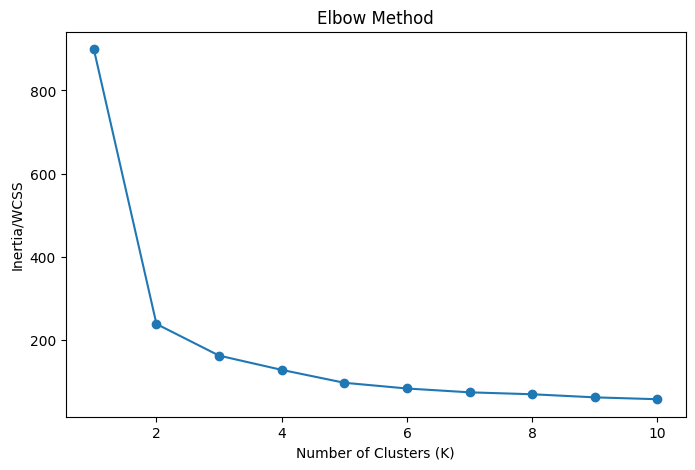

In [16]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),
         inertia_values,
         marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia/WCSS')
plt.show()

## 12. Train Final K-Means Model

In [17]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)
kmeans.fit(scaled_df)

KMeans(n_clusters=3, n_init=10, random_state=42)

## 13. Predict Cluster Labels

In [18]:
clusters = kmeans.predict(scaled_df)

scaled_df['Cluster'] = clusters

scaled_df.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Cluster
0,1.000000,0.112314,0.024393,0.076519,0.091720,0.140030,0.010791,0.006369,0.019608,0.0,1
1,0.333333,0.031847,0.000000,0.000000,0.031847,0.000000,0.000000,0.000000,0.000000,0.0,0
2,1.000000,0.048195,0.011243,0.016647,0.043312,0.031963,0.003597,0.006369,0.000000,0.0,1
3,0.333333,0.023567,0.000000,0.000000,0.023567,0.000000,0.000000,0.000000,0.000000,0.0,0
4,0.333333,0.045223,0.000000,0.000000,0.043312,0.013699,0.000000,0.000000,0.000000,0.0,0


## 14. Check Cluster Counts

In [20]:
scaled_df['Cluster'].value_counts()

Cluster
0    4139
1    2584
2     327
Name: count, dtype: int64

## 15. Evaluate Clustering using Silhouette Score

In [21]:
score = silhouette_score(
    scaled_df.drop('Cluster', axis=1), clusters)
print('Silhouette Score:', score)

Silhouette Score: 0.7838777714764834


## 16. Visualize Clusters

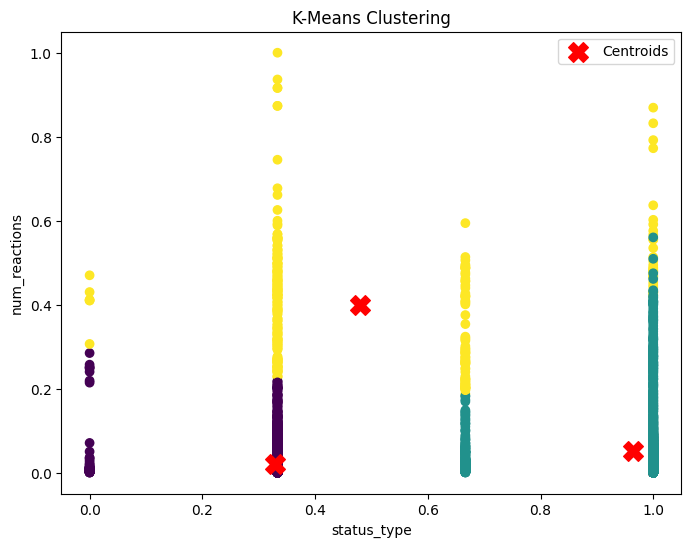

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(
    scaled_df.iloc[:, 0],
    scaled_df.iloc[:, 1],
    c=clusters,
    cmap='viridis'
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clustering')
plt.xlabel(scaled_df.columns[0])
plt.ylabel(scaled_df.columns[1])

plt.legend()

plt.show()

## 17. Step-by-Step Working of K-Means


### Step 1: Choose K
Example:
`K = 3`

### Step 2: Randomly Select Centroids

### Step 3: Calculate Distance

Euclidean Distance Formula:

d = √((x₂ − x₁)² + (y₂ − y₁)²)

### Step 4: Assign Points to Nearest Centroid

### Step 5: Recalculate Centroids

Centroid Formula:

Centroid = (x₁ + x₂ + ... + xₙ) / n

### Step 6: Repeat Until Stable


## 18. Advantages of K-Means


- Simple and fast
- Easy to understand
- Works well on large datasets
- Useful in customer segmentation


## 19. Limitations of K-Means


- Need to choose K manually
- Sensitive to outliers
- Different initialization may give different results


## 20. Real-World Applications


- Customer Segmentation
- Recommendation Systems
- Image Compression
- Fraud Detection
- Social Media Analysis


## Final Conclusion


In this implementation, we learned:

- Data preprocessing
- Feature scaling
- Elbow method
- K-Means clustering
- Cluster visualization
- Silhouette score

K-Means is one of the most important unsupervised machine learning algorithms.
